# Phase 2 (Obj B Short-Run): LP-IV Dynamics

This notebook focuses on short-run policy dynamics: LP-IV for inflation horizons (h=0..3) and GDP at h=0.

## Method summary

- Build exact horizon outcomes by matching country and calendar year.
- Estimate IV-TWFE per horizon with clustered standard errors by country.
- Report both coefficient significance and first-stage diagnostic strength.

In [1]:
from pathlib import Path
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels.iv import IV2SLS

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve() if (Path.cwd() / "macro_growth_merged.csv").exists() else Path.cwd().resolve().parents[0]
if not (ROOT / "macro_growth_merged.csv").exists():
    ROOT = Path.cwd().resolve().parents[1]

OUT_DIR = ROOT / "outputs/notebook_phase2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESTRICTED_CONTROLS = ["trade_open", "pop_growth", "investment_share"]
CHI2_1_95_CRITICAL = 3.841458820694124
STRONG_IV_STAT_THRESHOLD = 10.0
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

In [2]:
base = pd.read_csv(ROOT / "macro_growth_merged.csv")
controls = pd.read_csv(ROOT / "data/phase1_controls.csv")
instruments = pd.read_csv(ROOT / "data/phase1_instruments.csv")

panel = (
    base.merge(controls, on=["Country Name", "year"], how="left")
        .merge(instruments, on=["Country Name", "year"], how="left")
        .rename(columns={"Country Name": "country"})
        .sort_values(["country", "year"])
        .copy()
)

panel[["country", "year", "m2_growth", "inflation", "gdp_growth"]].head()

,country,year,m2_growth,inflation,gdp_growth
0,Afghanistan,2006,-1.586746,0.065644,0.052188
1,Afghanistan,2007,0.353436,0.083243,0.129504
2,Afghanistan,2008,0.272953,0.234429,0.038499
3,Afghanistan,2009,0.285518,-0.070542,0.193843
4,Afghanistan,2010,0.238600,0.021551,0.134203


In [3]:
def exact_horizon_series(source_df, target_df, value_col, horizon, entity_col="country", time_col="year", out_col=None):
    if horizon < 0:
        raise ValueError("horizon must be non-negative")

    out_col = out_col or f"{value_col}_h{horizon}"
    if horizon == 0:
        return target_df[value_col].copy()

    lookup = source_df[[entity_col, time_col, value_col]].dropna(subset=[value_col]).copy()
    lookup[time_col] = lookup[time_col] - horizon
    lookup = lookup.rename(columns={value_col: out_col}).drop_duplicates([entity_col, time_col], keep="last")
    aligned = target_df[[entity_col, time_col]].merge(lookup, on=[entity_col, time_col], how="left")
    return aligned[out_col]

horizons = {
    "inflation": [0, 1, 2, 3],
    "gdp_growth": [0],
}

lp_panel = panel.copy()
for outcome, hs in horizons.items():
    for h in hs:
        lp_panel[f"{outcome}_h{h}"] = exact_horizon_series(panel, lp_panel, outcome, h, out_col=f"{outcome}_h{h}")

lp_panel[["country", "year", "inflation_h0", "inflation_h1", "inflation_h2", "inflation_h3", "gdp_growth_h0"]].head()

,country,year,inflation_h0,inflation_h1,inflation_h2,inflation_h3,gdp_growth_h0
0,Afghanistan,2006,0.065644,0.083243,0.234429,-0.070542,0.052188
1,Afghanistan,2007,0.083243,0.234429,-0.070542,0.021551,0.129504
2,Afghanistan,2008,0.234429,-0.070542,0.021551,0.111579,0.038499
3,Afghanistan,2009,-0.070542,0.021551,0.111579,0.062423,0.193843
4,Afghanistan,2010,0.021551,0.111579,0.062423,0.071258,0.134203


In [4]:
def run_lp_iv(df, outcome, horizon, instrument):
    y_col = f"{outcome}_h{horizon}"
    cols = ["country", "year", y_col, "m2_growth", instrument, *RESTRICTED_CONTROLS]
    fit_data = df[cols].dropna().copy()

    formula = f"{y_col} ~ 1 + {' + '.join(RESTRICTED_CONTROLS)} + C(country) + C(year) [m2_growth ~ {instrument}]"
    res = IV2SLS.from_formula(formula, data=fit_data).fit(cov_type="clustered", clusters=fit_data["country"])

    fs = res.first_stage.diagnostics.loc["m2_growth"]
    coef = float(res.params["m2_growth"])
    se = float(res.std_errors["m2_growth"])

    return {
        "outcome": outcome,
        "horizon": horizon,
        "instrument": instrument,
        "coef_m2_growth": coef,
        "std_error": se,
        "p_value": float(res.pvalues["m2_growth"]),
        "ci_low_95": coef - 1.96 * se,
        "ci_high_95": coef + 1.96 * se,
        "nobs": int(res.nobs),
        "first_stage_stat": float(fs["f.stat"]),
        "first_stage_p": float(fs["f.pval"]),
    }

rows = []
for instrument in ["instrument_m2_external_level", "instrument_m2_l1"]:
    for outcome, hs in horizons.items():
        for h in hs:
            rows.append(run_lp_iv(lp_panel, outcome, h, instrument))

lp_table = pd.DataFrame(rows).sort_values(["instrument", "outcome", "horizon"])
primary = lp_table[lp_table["instrument"] == "instrument_m2_external_level"].copy()
alt = lp_table[lp_table["instrument"] == "instrument_m2_l1"].copy()

lp_table

,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_stat,first_stage_p
4,gdp_growth,0,instrument_m2_external_level,-0.119565,0.084488,1.570169e-01,-0.285160,0.046031,3535,4.224306,0.039849
0,inflation,0,instrument_m2_external_level,1.032654,0.266082,1.040428e-04,0.511134,1.554174,3535,4.224306,0.039849
1,inflation,1,instrument_m2_external_level,0.657150,0.223400,3.265395e-03,0.219286,1.095015,3387,4.543889,0.033036
2,inflation,2,instrument_m2_external_level,0.569717,0.251978,2.376047e-02,0.075840,1.063593,3243,4.936009,0.026303
3,inflation,3,instrument_m2_external_level,0.545100,0.256039,3.325655e-02,0.043263,1.046936,3102,4.764284,0.029056
9,gdp_growth,0,instrument_m2_l1,-0.023754,0.026796,3.753705e-01,-0.076275,0.028767,3409,6.280877,0.012205
5,inflation,0,instrument_m2_l1,1.507688,0.227172,3.206524e-11,1.062430,1.952946,3409,6.280877,0.012205
6,inflation,1,instrument_m2_l1,0.685303,0.091913,8.926193e-14,0.505153,0.865453,3262,5.219097,0.022340
7,inflation,2,instrument_m2_l1,0.309168,0.071666,1.603073e-05,0.168703,0.449633,3118,3.301674,0.069209
8,inflation,3,instrument_m2_l1,0.102434,0.067692,1.302182e-01,-0.030242,0.235111,2978,2.994118,0.083567


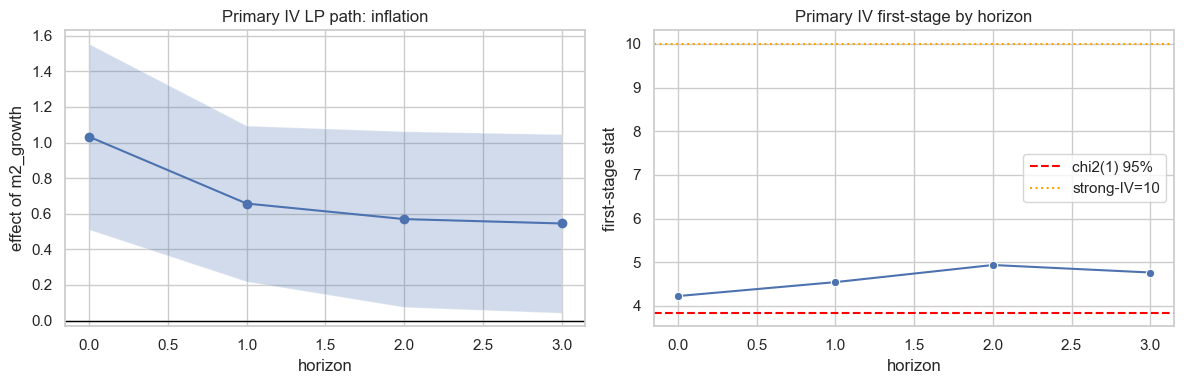

In [5]:
plot_data = primary[primary["outcome"] == "inflation"].sort_values("horizon")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(plot_data["horizon"], plot_data["coef_m2_growth"], marker="o")
axes[0].fill_between(plot_data["horizon"], plot_data["ci_low_95"], plot_data["ci_high_95"], alpha=0.25)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Primary IV LP path: inflation")
axes[0].set_xlabel("horizon")
axes[0].set_ylabel("effect of m2_growth")

sns.lineplot(data=primary.groupby(["horizon"], as_index=False)["first_stage_stat"].mean(), x="horizon", y="first_stage_stat", marker="o", ax=axes[1])
axes[1].axhline(CHI2_1_95_CRITICAL, color="red", linestyle="--", label="chi2(1) 95%")
axes[1].axhline(STRONG_IV_STAT_THRESHOLD, color="orange", linestyle=":", label="strong-IV=10")
axes[1].set_title("Primary IV first-stage by horizon")
axes[1].set_ylabel("first-stage stat")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT_DIR / "phase2_inflation_lp_and_first_stage.png", dpi=170)
plt.show()

In [6]:
infl_primary = primary[primary["outcome"] == "inflation"].copy()
gdp_primary = primary[primary["outcome"] == "gdp_growth"].copy()

metrics = pd.DataFrame([
    {"metric": "inflation_sig_horizons_5pct", "value": int((infl_primary["p_value"] < 0.05).sum())},
    {"metric": "gdp_sig_horizons_5pct", "value": int((gdp_primary["p_value"] < 0.05).sum())},
    {"metric": "inflation_min_first_stage_stat_primary", "value": float(infl_primary["first_stage_stat"].min())},
    {"metric": "inflation_relevance_gate_all_horizons", "value": bool((infl_primary["first_stage_stat"] > CHI2_1_95_CRITICAL).all())},
    {"metric": "inflation_strong_iv_all_horizons", "value": bool((infl_primary["first_stage_stat"] >= STRONG_IV_STAT_THRESHOLD).all())},
])

lp_table.to_csv(OUT_DIR / "phase2_lp_iv_all_results.csv", index=False)
primary.to_csv(OUT_DIR / "phase2_lp_iv_primary_results.csv", index=False)
alt.to_csv(OUT_DIR / "phase2_lp_iv_alt_results.csv", index=False)
metrics.to_csv(OUT_DIR / "phase2_interpretation_metrics.csv", index=False)

display(metrics)
print("Saved Phase 2 outputs to:", OUT_DIR)

,metric,value
0,inflation_sig_horizons_5pct,4
1,gdp_sig_horizons_5pct,0
2,inflation_min_first_stage_stat_primary,4.224306
3,inflation_relevance_gate_all_horizons,True
4,inflation_strong_iv_all_horizons,False


Saved Phase 2 outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/outputs/notebook_phase2


## Interpretation for short-run Obj B

- Positive inflation LP-IV responses can coexist with weak-to-moderate first-stage strength.
- Keep claims at associational/limited-causal level unless strong-IV diagnostics improve.
- Use this notebook as the policy-dynamics layer after Phase 1 baseline.